# How much locality can I buy with grouping?
Ning Yang

I used CSDP to study learning beyond approximations to backpropagation. I focus on one limitation: each goodness modulator reads traces across its whole layer. Can fixed groups shrink that dependency without losing too much accuracy?

This notebook runs source checks, reads every saved seed, and trains one fixed pair at the end. The experiments are small; the claim should be small too. Group/helper ideas already appear in the author's discussion. I am testing an implementation, not claiming a new learning principle.

CSDP: Ororbia (2024), [doi:10.1126/sciadv.adn6076](https://doi.org/10.1126/sciadv.adn6076). I kept the author's JAX/ngclearn code rather than porting it to snnTorch.

## The limitation, and the change I made

The published limitation is layer-wide goodness dependence, **not** a proven accuracy defect. My grouping adaptation reduces each instantaneous modulator's trace fan-in from 256/64 to 32/8 with G=8. That is the improvement measured here. Accuracy losses below are costs of the adaptation, not evidence that the original method was inaccurate.

For equal contiguous groups:
$$q_{bg}=G\sum_{i\in g}z_{bi}^2-10,\qquad L_G=\frac{1}{BG}\sum_{b,g}\mathrm{BCEWithLogits}(q_{bg},y_b).$$

G=1 keeps the original function. G=8 changes the loss: every group must provide evidence. It is not an equivalent rearrangement. For neuron $i$ in group $g$,
$$\frac{\partial L_G}{\partial z_{bi}}=\frac{2z_{bi}}{B}[\sigma(q_{bg})-y_b].$$
The G prefactor cancels; the sigmoid and gradient norms can still change. B=196 after adding 98 negative examples to the 98 positive ones. The author's batch-size rule uses learning rate 0.001 and activity decay 0.00007, despite the constructor argument 0.002.

All traces are still stored. Recurrent paths, shared labels and feedback remain. I have not measured a whole-network communication or energy saving.

In [1]:
import matplotlib.pyplot as plt
from src.config import describe_configs
from src.results import load_saved_results
from src.stats import analyse_results, print_seed_table, print_comparisons
from src.plotting import plot_paired_seeds, plot_failure_case, plot_supplement
from src.trainer import check_mechanisms, reproduce_first_pair

describe_configs()

primary: seeds=[12001, 12002, 12003, 12004, 12005, 12006, 12007, 12008, 12009, 12010, 12011, 12012, 12013, 12014, 12015, 12016, 12017, 12018, 12019, 12020], groups=[1, 8], epochs={1: 5, 8: 5}
supplement: seeds=[13001, 13002, 13003, 13004, 13005, 13006, 13007, 13008, 13009, 13010], groups=[1, 2, 4, 8, 16], epochs={1: 20, 2: 5, 4: 5, 8: 20, 16: 5}
Architecture: [64, 256, 64, 10]; raw batch: 98; contrastive batch: 196; T=50; dt=3.0
Requested eta: 0.002; actual eta: 0.001; activity decay: 7e-05; threshold: 10.0


The printed settings come from the frozen protocols. G=1 is a valid reference. Seeds are explicit lists, not sampled when this notebook starts.

CSDP uses JAX keys split before model initialization. The frozen data split has its own fixed scikit-learn seeds. Internal encoder keys evolve across training and validation; resetting them would change the experiment. The original audit checks initial weights and explicit streams; the supplement also records encoder-key boundaries. There is no PyTorch or CUDA random source in this implementation.

### Does grouping actually change the dependency?

I check the frozen source directly: G=1 against its original branch, analytic derivatives, and the response to perturbing one trace. These are synthetic mechanism checks, not evidence about classification. A separate process avoids ngcsimlib context collisions.

In [2]:
mechanism_output = check_mechanisms()

Source checks passed: original G1, derivatives and group support.


## Every seed stays in

Digits: 1,078 training and 359 validation images, ten classes, 8×8 pixels. The network is 64–256–64–10 with 141,568 weights. G=1 and G=8 share initial weights, sample order, training budget and random streams. The original endpoint is epoch 5 across 20 fixed seeds; the lower endpoint of the paired 95% t interval must exceed -1 pp.

I had already inspected this validation split in earlier work. These are conditional training-seed intervals, not independent-data confirmation.

To keep the repository small, `epochs.csv` contains all 750 saved epoch predictions and accuracies, plus hashes of the omitted probability arrays. The cell below recomputes accuracy from predictions. It cannot re-audit arrays that are not included; a fresh training run produces them again.

In [3]:
saved = load_saved_results()
print(f"Recomputed {len(saved.accuracy)} saved epoch accuracies; paired records match.")

Recomputed 750 saved epoch accuracies; paired records match.


In [4]:
comparisons = analyse_results(saved)
print_seed_table(saved, "primary", 5)
print_comparisons(comparisons, ["primary"])

primary, epoch 5: accuracy percentages
seed G      1 G      8
12001   88.022   87.744
12002   88.301   89.694
12003   89.972   88.858
12004   88.579   89.972
12005   89.972   89.694
12006   88.579   90.251
12007   87.187   88.022
12008   88.022   88.022
12009   89.694   89.694
12010   90.251   89.415
12011   89.415   89.415
12012   89.136   88.022
12013   89.972   89.136
12014   93.036   89.136
12015   89.415   90.251
12016   89.136   89.694
12017   89.972   89.415
12018   89.136   88.579
12019   88.579   89.972
12020   89.972   88.301
primary: -0.153 pp, 95% interval [-0.765, +0.459]; losses >1 pp: 4/20


The mean met the retention margin. I would not call that reliable across individual runs: four pairs lost more than 1 pp. Here are all twenty pairs.

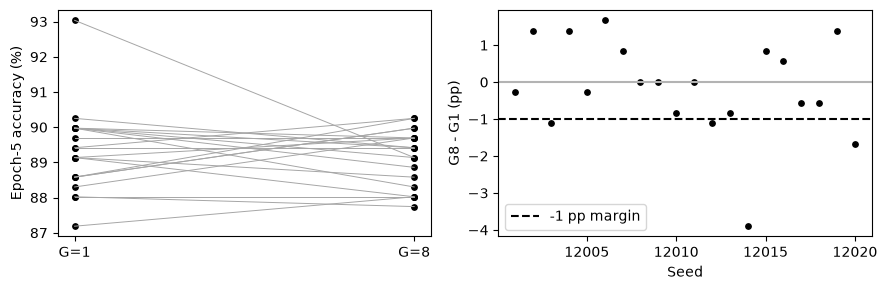

In [5]:
plot_paired_seeds(saved)
plt.show()

**Figure 1.** All 20 paired outcomes at epoch 5. The dashed line is the -1 pp retention margin, not a confidence interval.

## Observed failure: the run I would not hide

Seed 12014 ended 3.90 pp below G1. G8 was ahead at epoch 2 and behind at epoch 3. The paired differences across epochs 1–5 were -3.62, +5.57, -2.79, -2.51 and -3.90 pp. This is not a steady divergence story. I have not established its cause.

The original outcomes are 10 decreases, 3 ties and 7 increases. The four losses exceeding 1 pp are **not** four sign flips in the learning signal. I did not measure that.

### What I tried first

Before grouping, I tried a different constraint: fixed neuron output signs. A magnitude-decay variant gained only 0.37 pp over native decay across three development seeds, and one seed got worse. It missed the rule for continuing, so I stopped it. That was a separate experiment, not a failed version of grouping or a bug in original CSDP. [Short record](docs/NOTES.md).

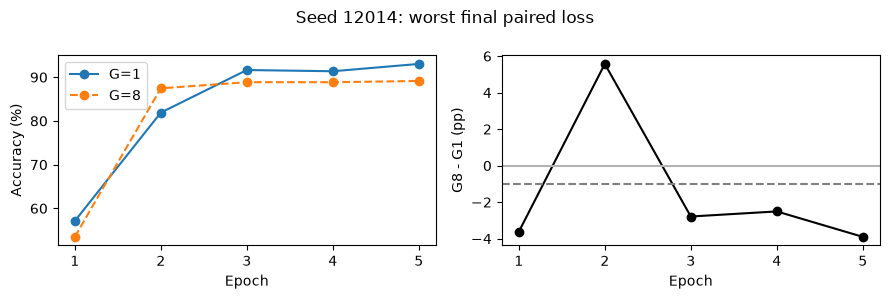

In [6]:
plot_failure_case(saved)
plt.show()

**Figure 2.** Worst final pair, seed 12014. G8 leads at epoch 2 and falls behind at epoch 3. I have not identified the mechanism behind the reversal.

## Does the result survive another budget?

After seeing the original results, I fixed G=1/2/4/8/16 and ten new seeds: 50 models. All groups run for five epochs; G1/G8 continue to twenty. I did not select a replacement G or best checkpoint from this curve.

The four epoch-5 comparisons use simultaneous 95% Bonferroni intervals (each 98.75%). The epoch-20 interval is a separate 95% check. I keep the original and extra seed cohorts separate.

In [7]:
print_seed_table(saved, "supplement", 5)
print_comparisons(comparisons, ["G2-G1", "G4-G1", "G8-G1", "G16-G1"])

supplement, epoch 5: accuracy percentages
seed G      1 G      2 G      4 G      8 G     16
13001   89.972   89.972   90.808   90.529   89.694
13002   85.794   87.465   86.908   86.630   87.744
13003   88.858   88.579   90.529   89.136   88.301
13004   89.972   90.529   90.251   89.136   90.808
13005   89.972   89.694   88.301   88.579   89.694
13006   92.201   90.529   90.808   91.365   90.251
13007   88.858   88.022   89.136   86.072   88.301
13008   90.251   89.694   87.744   89.972   90.251
13009   87.744   88.022   88.579   86.908   89.415
13010   90.529   91.365   90.529   89.415   89.972
G2-G1: -0.028 pp, simultaneous 95% interval [-0.945, +0.890]; losses >1 pp: 1/10
G4-G1: -0.056 pp, simultaneous 95% interval [-1.391, +1.279]; losses >1 pp: 3/10
G8-G1: -0.641 pp, simultaneous 95% interval [-1.683, +0.401]; losses >1 pp: 3/10
G16-G1: +0.028 pp, simultaneous 95% interval [-1.116, +1.172]; losses >1 pp: 1/10


In [8]:
print_seed_table(saved, "supplement", 20)
print_comparisons(comparisons, ["epoch20", "budget_interaction"])

supplement, epoch 20: accuracy percentages
seed G      1 G      8
13001   91.922   92.758
13002   90.529   90.808
13003   92.479   91.365
13004   93.036   92.479
13005   93.036   92.758
13006   91.922   92.479
13007   91.643   90.808
13008   91.922   91.365
13009   92.758   92.201
13010   93.036   92.758
epoch20: -0.251 pp, 95% interval [-0.696, +0.194]; losses >1 pp: 1/10
budget_interaction: +0.390 pp, descriptive 95% interval [-0.314, +1.094]


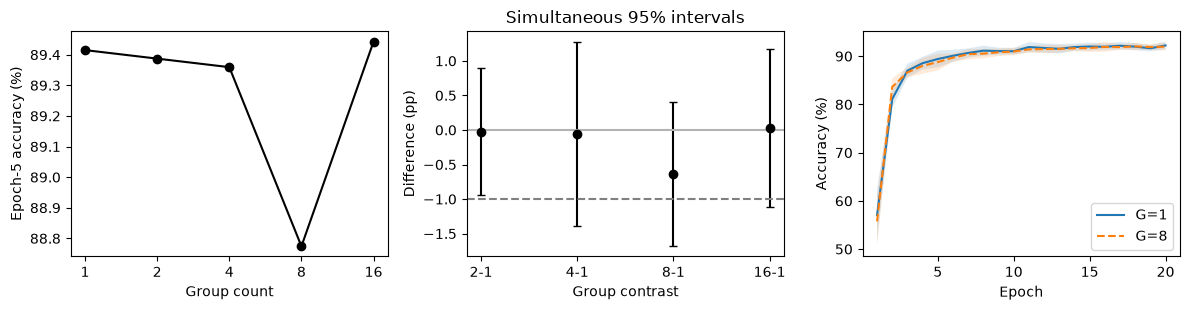

In [9]:
plot_supplement(saved, comparisons)
plt.show()

**Figure 3.** Left: five group counts, ten seeds each. Middle: four simultaneous 95% intervals. Right: G1/G8 through epoch 20; shading is ±1 seed SD, not a confidence interval.

## What I cannot conclude

The new five-epoch G8 result did **not** re-establish the -1 pp retention margin: -0.641 pp, simultaneous interval [-1.683, +0.401]. The twenty-epoch result did: -0.251 pp, separate 95% interval [-0.696, +0.194].

The change in the paired gap is +0.390 pp, with descriptive 95% interval [-0.314, +1.094]. I cannot conclude that longer training fixes the gap. Twenty epochs also does not prove convergence.

My conclusion is conditional: grouping reduces each goodness modulator's immediate trace dependence to one eighth. Accuracy retention held in some planned comparisons, not all. I have not shown a new algorithm, lower whole-network costs, patient privacy or clinical benefit.

### Open questions

I would first distinguish missing cross-group evidence from objective scaling or saturation. Only if the diagnostics support it would I test low-frequency cross-group summaries under a fixed information budget, against fixed grouping and simple periodic full-layer correction. That adds nonlocal information back. Its value and novelty need evidence on data not used to choose the method.

## Now train one pair

This uses seed 12001 and five epochs for each method, without overwriting saved results. It checks execution, not the twenty-pair statistical conclusion. The data are regenerated locally from scikit-learn and checked against frozen hashes. No download is needed after installing dependencies.

The next cell compares every fresh epoch's predictions and probability hash with the saved first pair. Exact agreement was obtained in the tested environment; a different platform may differ numerically and should be investigated, not silently accepted.

In [10]:
fresh_output = reproduce_first_pair(saved)

Both fresh models match all five saved epochs, including probability hashes.
Fresh records and logs: fresh_runs/notebook_pair_20261007T141901662086Z
